In [65]:
import deepxde as dde
#from deepxde.backend import tf 
#setting the backend, only works for tf, not jax/pytorch
dde.backend.backend_name = "pytorch" #for pytorch backend

import numpy as np
import matplotlib.pyplot as plt
import torch

In [66]:
#Defing the pde function
def pde(x, y):
    dy_xx = dde.grad.hessian(y, x) #calculates the second derivative of y w.r.t x.
    return dy_xx + np.pi**2 * tf.sin(np.pi*x) #returns the value of the pde

In [67]:
#defining the geometry/interval
geom = dde.geometry.Interval(-1, 1) #defines a 1D interval from [-1, 1].
#Can use dde.geometry.Rectangle for 2D problems.

In [68]:
#define the boundary functions
def boundary(x, on_boundary):
    return on_boundary

def boundary_func(x):
    return 0

In [69]:
def boundary_flux_r(x):
    return 4

#for the neumannBC

In [70]:
def exact_sol(x):
    return tf.sin(np.pi*x)

#exact solution of the pde

In [71]:
#Robin Boundary condition(hybrid of dirichlet and neumann)
def boundary_func_robin(X, y):
    return y

bc_robin = dde.icbc.RobinBC(geom, boundary_func_robin, boundary_func) 
#Can use this as the right side boundary 

In [72]:
bc_l = dde.icbc.DirichletBC(geom, boundary_func, boundary)
bc_r = dde.icbc.NeumannBC(geom, boundary_flux_r, boundary) 
#can use dde.icbc.NeumannBC(geom, boundary_func, boundary) for the neumann conditions. We can use Dirich for left and Neumann for right boundaries.
#uses boundary to check if its a boundary value or not and then sets its value using the boundary func

data = dde.data.PDE(geom, pde, [bc_l, bc_r], 16, 2,num_test=100, solution=exact_sol) #16 is the number of training points sampled from the domain[-1, 1]
#num_tests is the number of test points sampled from the domain. The 2 is the number of boundary conditions
#defing the governing equation

In [73]:
layer_size = [1] + [50]*3 + [1] #1 input layer with 1 neuron, 3 hidden layers with 50 neurons each and 1 output layer with 1 neuron.
activation = "tanh"
initializer = "Glorot uniform" #initializing the weights
net = dde.nn.FNN(layer_size, activation, initializer)



In [74]:
model = dde.Model(data, net) #initializing the model
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

losshistory, train_stats = model.train(iterations=1000)

Compiling model...
'compile' took 0.003132 s

Training model...



/media/srimukha-sarma/Windows-SSD/conda-envs/deepxde/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Step      Train loss                        Test loss                         Test metric   
0         [4.42e+01, 5.09e-02, 1.60e+01]    [5.00e+01, 5.09e-02, 1.60e+01]    [1.16e+00]    
1000      [2.52e+00, 5.17e-01, 1.68e+00]    [6.28e+01, 5.17e-01, 1.68e+00]    [9.38e-01]    

Best model at step 1000:
  train loss: 4.72e+00
  test loss: 6.50e+01
  test metric: [9.38e-01]

'train' took 1.512497 s



In [75]:
X = geom.uniform_points(10)
periodic_points = bc_r.collocation_points(X)
#collocation points are the points where the boundary condition is applicable(depends on the boundary_r function)

print(periodic_points)

[[-1.]
 [ 1.]]


In [79]:
inputs = torch.tensor(periodic_points, dtype=torch.float32)
inputs.requires_grad_(True)
outputs = torch.tensor(model.predict(periodic_points), dtype=torch.float32)

beg, end = 0, len(periodic_points)

In [80]:
residual = bc_r.error(X, inputs, outputs, beg, end) #the residual error(total - boundary error)

mse_residual = torch.mean(residual**2)

print(mse_residual.item())

AttributeError: 'Tensor' object has no attribute 'ref'

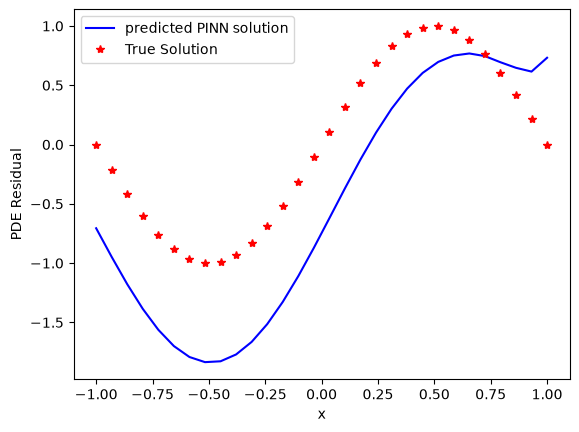

In [57]:
#plot the pde residual
x = geom.uniform_points(30, True)
y_pred = model.predict(x)
y_exact = exact_sol(x)
plt.figure()
plt.plot(x, y_pred, color='b', label="predicted PINN solution")
plt.plot(x, y_exact, '*', color='r', label="True Solution")
plt.xlabel("x")
plt.ylabel("PDE Residual")
plt.legend(loc='best')
plt.show()

